chmod +x autorun_k0r1.sh
nohup ./autorun_k0r1.sh > autorun23.nohup.log 2>&1 &

kill -9 xxxxxxx

pkill -f run_seq.sh

cd D:\Git\SnapKV\experiments\LongBench

python eval_auto.py --model all

cd D:\Git\SnapKV\experiments\LongBench\results

python collect_qasper_scores_kr.py


可以。你现在这版 SnapKV 的核心逻辑是：在 `snapkv_utils_without_comp.py` 的 `SnapKVCluster.update_kv()` 中，根据观察窗口 attention score 选出旧 token 的 topK，然后只把 `topK old tokens + window tokens` 拼回 cache，剩余 token 直接消失；hijack 文件中则在 prefill/cache 初始化阶段调用 `self.kv_cluster.update_kv(...)`，然后把压缩后的 dense KV 写入 `past_key_value.update(...)`。 

我给你做了一个**可直接移植的 correctness-first 版本**：保留 SnapKV 的 topK 选择逻辑不变，但把原本被丢弃的 token 变成 **KIVI-style 2-bit group-wise affine quantized cache** 存在 attention layer 自己的属性里；decode 时再临时 dequantize，与 dense retained KV 一起参与 attention。

文件如下：

[下载 snapkv_utils_kivi_comp.py](sandbox:/mnt/data/snapkv_utils_kivi_comp.py)
[下载 mistral_hijack_4_37_snapkv_kivi.py](sandbox:/mnt/data/mistral_hijack_4_37_snapkv_kivi.py)

---

## 1. 加入方式总览

改造后的 cache 结构变成两部分：

| 部分                    | 存储对象                              |                      精度 | 作用                                                                  |
| --------------------- | --------------------------------- | ----------------------: | ------------------------------------------------------------------- |
| SnapKV retained cache | `past_key_value` / `DynamicCache` |               fp16/bf16 | 保存 SnapKV 选中的 topK old tokens + window tokens + 后续 generated tokens |
| SnapKV dropped cache  | `self.snapkv_kivi_dropped_cache`  | KIVI-style 2-bit packed | 保存原本会被 SnapKV 丢弃的 old tokens                                        |
| Decode attention      | 手写 PyTorch attention              |                      混合 | 对 `dequant(dropped) + retained_dense` 一起计算 attention                |

也就是说，**DynamicCache 仍然只存 full-precision retained tokens**，这样不会破坏 HuggingFace 的缓存接口；额外的量化 dropped tokens 单独挂在每层 attention 模块上。

---

## 2. 量化逻辑如何对应 KIVI

我在 `snapkv_utils_kivi_comp.py` 中实现了一个纯 PyTorch 的 KIVI-style quantizer：

```python
class KIVIUniformQuantizer:
    quantize_key_per_channel(...)
    quantize_value_per_token(...)
    dequantize_key_per_channel(...)
    dequantize_value_per_token(...)
```

它采用 KIVI 的核心量化思想：

| 对象    | 量化方式                                              | 代码实现                             |
| ----- | ------------------------------------------------- | -------------------------------- |
| Key   | per-channel，也就是对每个 head_dim channel 沿 token 维分组量化 | `key.transpose(-1, -2)` 后沿最后一维量化 |
| Value | per-token，也就是每个 token 的 value vector 内部分组量化       | 直接沿 head_dim 量化                  |
| 量化公式  | group-wise min-max affine                         | `q = round((x - mn) / scale)`    |
| 存储    | `packed uint8 + scale + mn`                       | 2-bit 时 1 byte 存 4 个值            |

这里没有使用 KIVI 官方 CUDA kernel，而是用 PyTorch 实现 bit-pack/dequant，方便你先做准确率实验。它是**功能正确优先**，不是速度最优。

---

## 3. SnapKV 丢弃逻辑的具体改法

原始逻辑是：

```python
indices = attn_cache.topk(self.max_capacity_prompt - self.window_size, dim=-1).indices
k_past_compress = key_states[:, :, :-self.window_size, :].gather(...)
v_past_compress = value_states[:, :, :-self.window_size, :].gather(...)
key_states = torch.cat([k_past_compress, k_cur], dim=2)
value_states = torch.cat([v_past_compress, v_cur], dim=2)
return key_states, value_states
```

新逻辑变成：

```python
keep_idx = topk(...)
drop_idx = all_old_indices - keep_idx

k_past_keep = gather(old_k, keep_idx)
v_past_keep = gather(old_v, keep_idx)

k_drop = gather(old_k, drop_idx)
v_drop = gather(old_v, drop_idx)

dropped_cache = SnapKVKIVIDroppedCache(
    key_q=quantize_key_per_channel(k_drop),
    value_q=quantize_value_per_token(v_drop),
    dropped_len=drop_len,
)

key_retained = cat([k_past_keep, k_cur])
value_retained = cat([v_past_keep, v_cur])
return key_retained, value_retained, dropped_cache
```

所以，SnapKV 的“重要 token 选择器”完全保留；变化只是：**不重要 token 不再直接丢，而是进入 KIVI 量化旁路 cache**。

---

## 4. hijack 中的注意力路径如何改

原始 hijack 在 prefill/cache 初始化时直接：

```python
key_states_compress, value_states_compress = self.kv_cluster.update_kv(...)
past_key_value.update(key_states_compress, value_states_compress, ...)
```

然后 FlashAttention 只看到压缩后的 dense KV。

我给出的新 hijack 做了三件事。

第一，**prefill 仍用 full KV 计算 attention output**，避免 prompt hidden states 本身被压缩 KV 影响。计算完后，只把 cache 存成：

```python
retained full KV -> DynamicCache
dropped quantized KV -> self.snapkv_kivi_dropped_cache
```

第二，decode 时先把当前 token 追加进 DynamicCache：

```python
dense_key_states, dense_value_states = past_key_value.update(...)
```

第三，如果该层存在 dropped quantized cache，就执行：

```python
k_drop = dequantize_key_per_channel(...)
v_drop = dequantize_value_per_token(...)

all_k = torch.cat([k_drop, dense_key_states], dim=2)
all_v = torch.cat([v_drop, dense_value_states], dim=2)

attn = softmax(q @ all_k.T / sqrt(d))
out = attn @ all_v
```

这样，decode 阶段注意力会同时看见：

```text
被 SnapKV 保留的 full tokens
+ 最近 window / generated full tokens
+ 原本被丢弃但现在 2-bit 量化保存的 tokens
```

---

## 5. 使用方法

把两个文件放到你的 SnapKV monkeypatch 目录，例如：

```bash
cp snapkv_utils_kivi_comp.py /home/ymz/SnapKV/SnapKV/snapkv/monkeypatch/
cp mistral_hijack_4_37_snapkv_kivi.py /home/ymz/SnapKV/SnapKV/snapkv/monkeypatch/
```

然后在你原来注册 Mistral hijack 的地方，把 forward 替换为新文件中的：

```python
from snapkv.monkeypatch.mistral_hijack_4_37_snapkv_kivi import (
    mistral_flash_attn2_forward,
    prepare_inputs_for_generation_mistral,
)
```

并在加载模型后设置：

```python
model.config.window_size = 32
model.config.max_capacity_prompt = 2048
model.config.kernel_size = 5
model.config.pooling = "avgpool"

model.config.snapkv_quant_dropped = True
model.config.kivi_bits = 2
model.config.kivi_group_size = 32
```

`max_capacity_prompt` 的含义保持 SnapKV 原样：full-precision retained cache 最多保留 `max_capacity_prompt` 个 prompt KV，其中包括 `window_size` 个最近 token。额外被丢弃的部分会进入量化 cache。

---

## 6. 这个版本和官方 KIVI 的区别

这个版本是为了让你快速验证“**SnapKV 丢弃 token 改成量化保存是否提升精度**”，所以我没有强依赖 KIVI 官方 CUDA 扩展。

| 项目       | 我给你的版本                      | 官方 KIVI 高性能版本             |
| -------- | --------------------------- | ------------------------- |
| 量化公式     | KIVI-style min-max affine   | KIVI min-max affine       |
| Key      | per-channel                 | per-channel               |
| Value    | per-token                   | per-token                 |
| bit-pack | PyTorch `uint8` pack        | CUDA/Triton int32 pack    |
| decode   | dequantize 后 PyTorch matmul | fused dequant + GEMV CUDA |
| 优点       | 易移植、易改、易 debug              | 快                         |
| 缺点       | decode 会慢，且 dequant 有临时显存   | 移植复杂                      |

如果你后续要跑速度，需要把这几个官方 KIVI 模块再接进来：

```text
KIVI-main/quant/new_pack.py
KIVI-main/quant/matmul.py
KIVI-main/quant/csrc/gemv_cuda.cu
KIVI-main/quant/csrc/gemv_cuda.h
KIVI-main/quant/csrc/pybind.cpp
KIVI-main/quant/setup.py
```

但对你当前研究问题，我建议先用我给的 PyTorch 版验证精度。如果精度收益明显，再把 dequant+matmul 替换成 KIVI CUDA kernel。

---

## 7. 当前版本的限制

这个版本有几个重要限制：

1. **速度不是最终目标**：decode 时会把 dropped KV 临时 dequantize 后再 matmul，适合做 accuracy ablation，不适合最终吞吐测试。
2. **主要面向 batch=1 或少 padding 的 LongBench 场景**：因为 dropped tokens 和 retained tokens 的顺序被拆开，复杂 padding mask 需要额外维护原始 token mask。
3. **被量化的是 post-RoPE Key**：这和你现有 SnapKV 代码一致；如果你要改成 pre-RoPE KIVI/KVQuant 风格，需要在 RoPE 前保存 K，并在 decode attention 前按原位置补 RoPE，改动会更大。
4. **DynamicCache 只存 dense retained tokens**：逻辑总长度由 `self.kv_seq_len` 维护，因此不要直接用 `past_key_value.get_seq_length()` 当作原始上下文长度。

---

## 8. 建议的实验对比

你可以按下面顺序做 ablation：

| 实验                           | 设置                                       |
| ---------------------------- | ---------------------------------------- |
| 原始 SnapKV                    | 直接丢弃不重要 token                            |
| SnapKV + KIVI dropped 2bit   | `snapkv_quant_dropped=True, kivi_bits=2` |
| SnapKV + KIVI dropped 4bit   | `kivi_bits=4`                            |
| SnapKV + full dropped oracle | 临时把 dropped cache 不量化，只存 fp16，用来估计上限     |
| 不同 group size                | `kivi_group_size=16/32/64`               |

如果 `SnapKV + KIVI dropped 2bit` 明显优于原始 SnapKV，说明“不重要 token 的近似 KV 信息”确实有价值；如果 4bit 明显强于 2bit，说明量化误差是主要瓶颈；如果 fp16 dropped oracle 仍提升不大，说明 SnapKV 丢掉的 token 对该任务本来就不重要。


#### 实验记录20260527
改了一版KIVI+snapkv的
- 丢弃的token使用KIVI风格量化

能跑一些但是后面OOM
- 看了输出，输出是正常的，说明量化后没有像latent一样破坏注意力
- 正常，因为量化之后一直存储在显存里，然后对话多了就爆了
- 分析还有反量化会导致峰值接近全KV，要做分块反量化

不拼接deopped+dense KV：
每次分块解码，这和对 [dropped KV + dense KV] 做完整 softmax 是等价的
（原来是attn = softmax(q @ all_k.T)）
```
for chunk in dropped_cache:
    k_chunk = dequantize_key_chunk(...)
    logits_chunk = q @ k_chunk.T
    update_global_max(...)

dense_logits = q @ dense_key_states.T
update_global_max(...)

for chunk in dropped_cache:
    k_chunk = dequantize_key_chunk(...)
    v_chunk = dequantize_value_chunk(...)
    weights_chunk = exp(logits_chunk - global_max)
    out += weights_chunk @ v_chunk
    denom += weights_chunk.sum(...)

dense_weights = exp(dense_logits - global_max)
out += dense_weights @ dense_value_states
denom += dense_weights.sum(...)

out = out / denom
```

每次反量化只反量化需要计算的token chunk，降低峰值

还是爆，而且每次都爆在同一个地方：
```
Answer:Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  0%|          | 1/200 [00:05<18:10,  5.48s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  1%|          | 2/200 [00:11<19:04,  5.78s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  2%|▏         | 3/200 [00:16<17:54,  5.46s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  2%|▏         | 4/200 [00:19<13:58,  4.28s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  2%|▎         | 5/200 [00:31<23:37,  7.27s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  3%|▎         | 6/200 [00:32<17:02,  5.27s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  4%|▎         | 7/200 [00:37<16:03,  4.99s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  4%|▍         | 8/200 [00:46<20:20,  6.36s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  4%|▍         | 9/200 [00:49<17:04,  5.36s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  5%|▌         | 10/200 [00:58<20:07,  6.35s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  6%|▌         | 11/200 [01:02<17:45,  5.64s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  6%|▌         | 12/200 [01:03<13:01,  4.16s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  6%|▋         | 13/200 [01:05<11:10,  3.58s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  7%|▋         | 14/200 [01:10<12:42,  4.10s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  8%|▊         | 15/200 [01:11<09:55,  3.22s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.

  8%|▊         | 15/200 [01:14<15:23,  4.99s/it]

```

应该是因为KIVI自己量化的越存越多。考虑量化也加个上限（正好对应原来计划里面的量化逐渐衰减然后删除）
```
# KIVI 量化旁路最大容量
# -1：不限制
#  0：完全不保存 dropped token，相当于原始 SnapKV 丢弃
#  N：每层每 head 最多保留 N 个被 SnapKV 丢弃的 token，超出后丢弃最旧 dropped tokens
model.config.kivi_max_capacity = 4096
```


无补偿性能（对照组）

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 28.78      |
| 32   | 1024   | 无补偿    | -     | 312     | 29.57      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.44      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.71      |


KIVI4096

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 32.72      |
| 32   | 1024   | 无补偿    | -     | 312     | 32.14      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.49      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.1      |



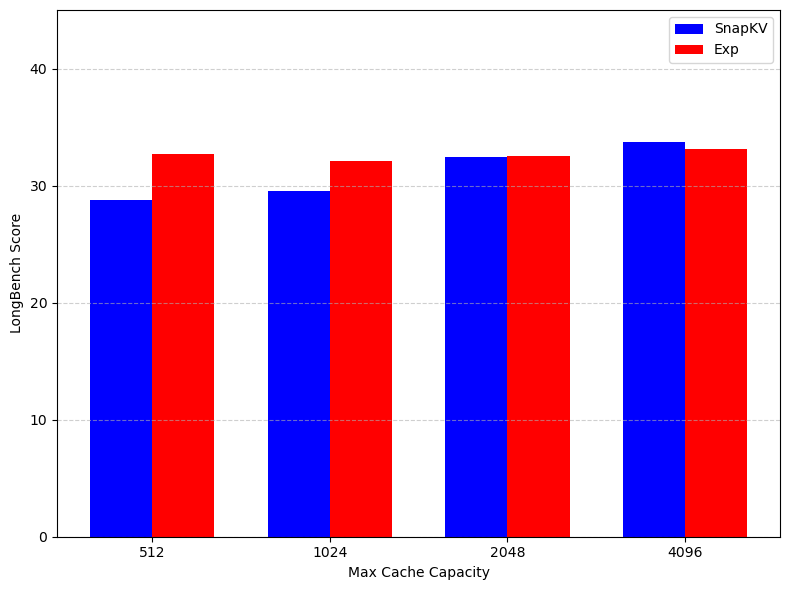

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data for SnapKV
max_cache_no_comp = [512, 1024, 2048, 4096]
longbench_no_comp = [28.78, 29.57, 32.44, 33.71]

# Data for Exp
max_cache_vae = [512, 1024, 2048, 4096]
longbench_vae = [32.72, 32.14, 32.49, 33.1]

# 将 x 轴转成等间距位置，避免 512/1024/2048/4096 间距不均导致柱子太宽或重叠
x = np.arange(len(max_cache_no_comp))

bar_width = 0.35

plt.figure(figsize=(8, 6))

# 左右错开画两组柱状图
plt.bar(
    x - bar_width / 2,
    longbench_no_comp,
    width=bar_width,
    label='SnapKV',
    color='b'
)

plt.bar(
    x + bar_width / 2,
    longbench_vae,
    width=bar_width,
    label='Exp',
    color='r'
)

# Labels
plt.xlabel('Max Cache Capacity')
plt.ylabel('LongBench Score')

# 设置 x 轴刻度标签
plt.xticks(x, max_cache_no_comp)

plt.yticks(np.arange(0, 50, step=10))
plt.ylim(0, 45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


无补偿性能（对照组）

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 28.78      |
| 32   | 1024   | 无补偿    | -     | 312     | 29.57      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.44      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.71      |


KIVI4096 K0R1

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|------------|
| 32   | 512    | 无补偿    | -     | 312     | 32.72      |
| 32   | 1024   | 无补偿    | -     | 312     | 32.14      |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.49      |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.1      |



KIVI4096 K3R7

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|-------------|
| 32   | 512    | 无补偿    | -     | 312     | 32.31       |
| 32   | 1024   | 无补偿    | -     | 312     | -           |
| 32   | 2048   | 无补偿   | 18485 | 311     | 31.93       |
| 32   | 4096   | 无补偿   | 20430 | 336     | 33.22        |


KIVI4096 K5R5

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|-------------|
| 32   | 512    | 无补偿    | -     | 312     | 34.05       |
| 32   | 1024   | 无补偿    | -     | 312     | 32.14         |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.29       |
| 32   | 4096   | 无补偿   | 20430 | 336     | 32.84        |



KIVI4096 K7R3

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|-------------|
| 32   | 512    | 无补偿    | -     | 312     | -           |
| 32   | 1024   | 无补偿    | -     | 312     | 31.94       |
| 32   | 2048   | 无补偿   | 18485 | 311     | -           |
| 32   | 4096   | 无补偿   | 20430 | 336     | -           |



KIVI4096 K1R0

| 窗口大小 | 最大缓存容量 | 补偿块大小 | 显存消耗  | 推理速度(s) | LongBench得分 |
|------|--------|-------|-------|---------|-------------|
| 32   | 512    | 无补偿    | -     | 312     | 32.72           |
| 32   | 1024   | 无补偿    | -     | 312     | 31.84       |
| 32   | 2048   | 无补偿   | 18485 | 311     | 32.49           |
| 32   | 4096   | 无补偿   | 20430 | 336     | 32.92           |

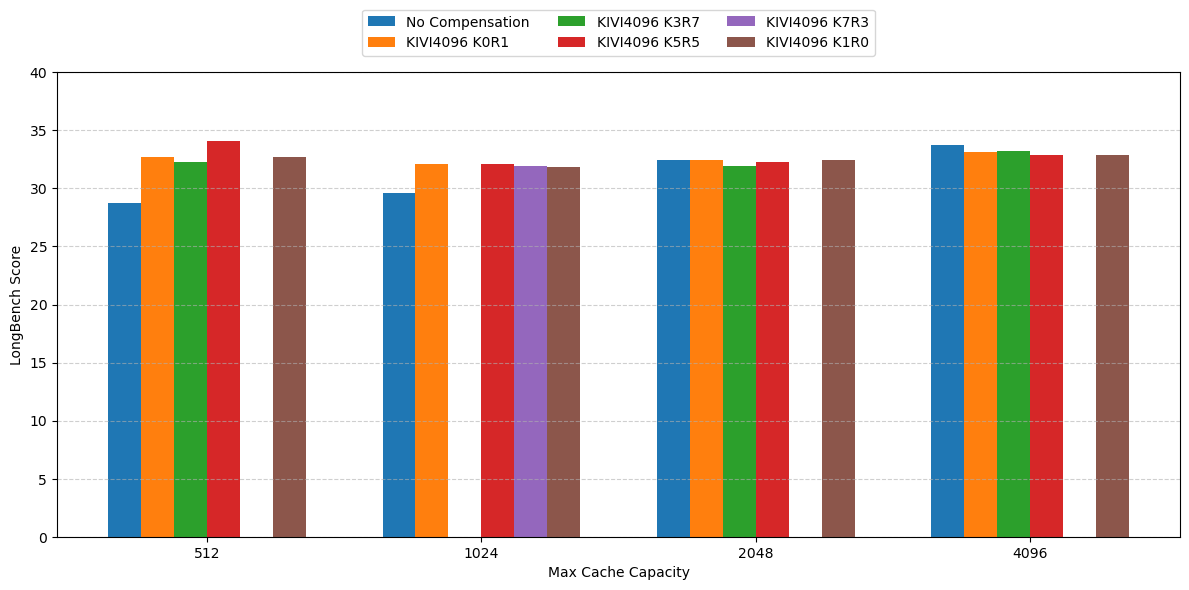

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# X-axis: Max Cache Capacity
max_cache = [512, 1024, 2048, 4096]

# LongBench scores
no_compensation = [28.78, 29.57, 32.44, 33.71]
kivi4096_k0r1 = [32.72, 32.14, 32.49, 33.10]
kivi4096_k3r7 = [32.31, 0, 31.93, 33.22]   # "-" treated as 0
kivi4096_k5r5 = [34.05, 32.14, 32.29, 32.84]
kivi4096_k7r3 = [0, 31.94, 0, 0]           # "-" treated as 0
kivi4096_k1r0 = [32.72, 31.84, 32.49, 32.92]

# Use equally spaced positions for grouped bars
x = np.arange(len(max_cache))

# Six groups of bars
num_groups = 6
bar_width = 0.12

# Center all six bars around each x-axis position
offsets = (np.arange(num_groups) - (num_groups - 1) / 2) * bar_width

plt.figure(figsize=(12, 6))

plt.bar(
    x + offsets[0],
    no_compensation,
    width=bar_width,
    label='No Compensation'
)

plt.bar(
    x + offsets[1],
    kivi4096_k0r1,
    width=bar_width,
    label='KIVI4096 K0R1'
)

plt.bar(
    x + offsets[2],
    kivi4096_k3r7,
    width=bar_width,
    label='KIVI4096 K3R7'
)

plt.bar(
    x + offsets[3],
    kivi4096_k5r5,
    width=bar_width,
    label='KIVI4096 K5R5'
)

plt.bar(
    x + offsets[4],
    kivi4096_k7r3,
    width=bar_width,
    label='KIVI4096 K7R3'
)

plt.bar(
    x + offsets[5],
    kivi4096_k1r0,
    width=bar_width,
    label='KIVI4096 K1R0'
)

# Axis labels
plt.xlabel('Max Cache Capacity')
plt.ylabel('LongBench Score')

# X-axis tick labels
plt.xticks(x, max_cache)

# Y-axis range and grid
plt.yticks(np.arange(0, 41, step=5))
plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.show()

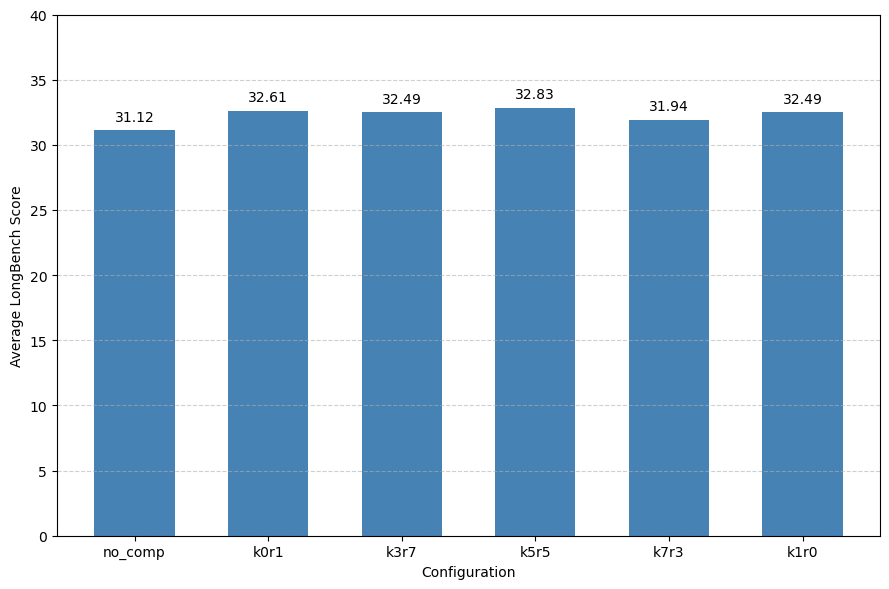

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# LongBench scores for each table
# "-" values are treated as 0
data = {
    'no_comp': [28.78, 29.57, 32.44, 33.71],
    'k0r1':    [32.72, 32.14, 32.49, 33.10],
    'k3r7':    [32.31,  31.93, 33.22],
    'k5r5':    [34.05, 32.14, 32.29, 32.84],
    'k7r3':    [ 31.94],
    'k1r0':    [32.72, 31.84, 32.49, 32.92],
}

# Calculate the average LongBench score for each table
labels = list(data.keys())
average_scores = [np.mean(scores) for scores in data.values()]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    labels,
    average_scores,
    color='steelblue',
    width=0.6
)

plt.xlabel('Configuration')
plt.ylabel('Average LongBench Score')
plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 5))
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display average values above bars
for bar, score in zip(bars, average_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{score:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
no_comp_512 = [28.78]
no_comp_1024 = [29.57]
no_comp_2048 = [32.44]
no_comp_4096 = [33.71]
c512_k0r1 = [32.53, 32.53, 32.53, 32.53, 32.53, 32.53]
c512_k3r7 = [32.53, 32.53, 32.53, 32.53, 32.53]
c512_k5r5 = [32.53, 32.53, 32.53, 32.53, 32.53]
c512_k7r3 = [32.53, 32.53, 32.53, 32.53]
c512_k1r0 = [32.53, 32.53, 32.53, 32.53, 32.53]
c1024_k0r1 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k3r7 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k5r5 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k7r3 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k1r0 = [31.89, 31.89, 31.89, 31.89, 31.89]
c2048_k0r1 = [32.38, 32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k3r7 = [32.38, 32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k5r5 = [32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k7r3 = [32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k1r0 = [32.38, 32.38, 32.38, 32.38, 32.38]
c4096_k0r1 = [32.44, 32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k3r7 = [32.44, 32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k5r5 = [32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k7r3 = [32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k1r0 = [32.44, 32.44, 32.44, 32.44, 32.44]

#没对，全是一个随机数种子，重来

图 1：不同容量、不同配置的统计结果

容量 = 512
  No compensation : n=1, mean=28.78, std=0.00
  k0r1            : n=6, mean=32.53, std=0.00
  k3r7            : n=5, mean=32.53, std=0.00
  k5r5            : n=5, mean=32.53, std=0.00
  k7r3            : n=4, mean=32.53, std=0.00
  k1r0            : n=5, mean=32.53, std=0.00

容量 = 1024
  No compensation : n=1, mean=29.57, std=0.00
  k0r1            : n=5, mean=31.89, std=0.00
  k3r7            : n=5, mean=31.89, std=0.00
  k5r5            : n=5, mean=31.89, std=0.00
  k7r3            : n=5, mean=31.89, std=0.00
  k1r0            : n=5, mean=31.89, std=0.00

容量 = 2048
  No compensation : n=1, mean=32.44, std=0.00
  k0r1            : n=6, mean=32.38, std=0.00
  k3r7            : n=6, mean=32.38, std=0.00
  k5r5            : n=5, mean=32.38, std=0.00
  k7r3            : n=5, mean=32.38, std=0.00
  k1r0            : n=5, mean=32.38, std=0.00

容量 = 4096
  No compensation : n=1, mean=33.71, std=0.00
  k0r1            : n=6, mean=32.44, std=0.00
  k3r7            

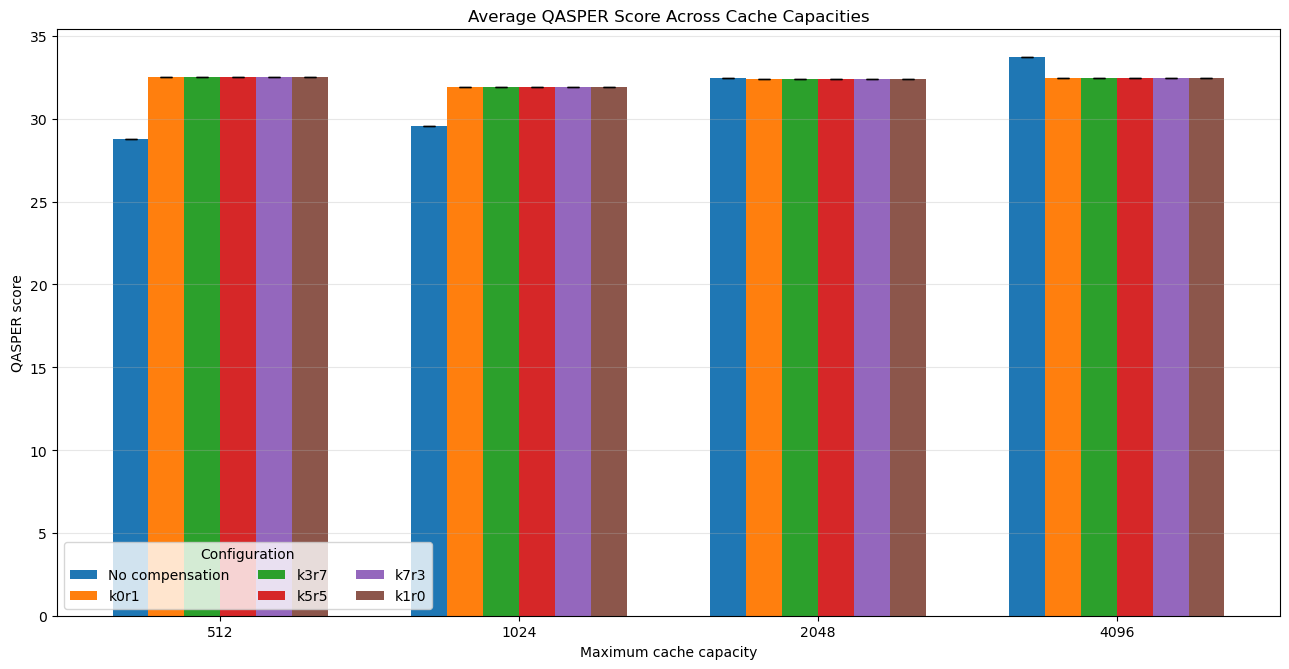

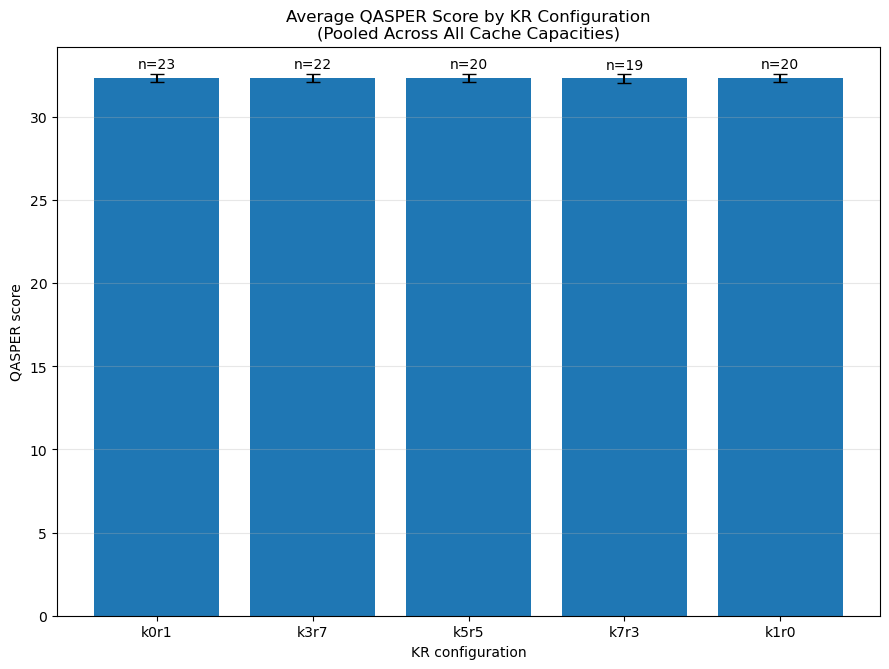

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 将 collect_qasper_scores.py 打印出的数组复制到这里
# ============================================================
no_comp_512 = [28.78]
no_comp_1024 = [29.57]
no_comp_2048 = [32.44]
no_comp_4096 = [33.71]
c512_k0r1 = [32.53, 32.53, 32.53, 32.53, 32.53, 32.53]
c512_k3r7 = [32.53, 32.53, 32.53, 32.53, 32.53]
c512_k5r5 = [32.53, 32.53, 32.53, 32.53, 32.53]
c512_k7r3 = [32.53, 32.53, 32.53, 32.53]
c512_k1r0 = [32.53, 32.53, 32.53, 32.53, 32.53]
c1024_k0r1 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k3r7 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k5r5 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k7r3 = [31.89, 31.89, 31.89, 31.89, 31.89]
c1024_k1r0 = [31.89, 31.89, 31.89, 31.89, 31.89]
c2048_k0r1 = [32.38, 32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k3r7 = [32.38, 32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k5r5 = [32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k7r3 = [32.38, 32.38, 32.38, 32.38, 32.38]
c2048_k1r0 = [32.38, 32.38, 32.38, 32.38, 32.38]
c4096_k0r1 = [32.44, 32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k3r7 = [32.44, 32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k5r5 = [32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k7r3 = [32.44, 32.44, 32.44, 32.44, 32.44]
c4096_k1r0 = [32.44, 32.44, 32.44, 32.44, 32.44]

# ============================================================
# 2. 基础配置
# ============================================================

CAPACITIES = [512, 1024, 2048, 4096]
KR_CONFIGS = ["k0r1", "k3r7", "k5r5", "k7r3", "k1r0"]

# 图 1 中的柱子顺序：对照组 + 5 种 KR 配置
SERIES = ["no_comp"] + KR_CONFIGS

SERIES_LABELS = {
    "no_comp": "No compensation",
    "k0r1": "k0r1",
    "k3r7": "k3r7",
    "k5r5": "k5r5",
    "k7r3": "k7r3",
    "k1r0": "k1r0",
}


# ============================================================
# 3. 工具函数
# ============================================================

def mean_and_std(values):
    """
    返回：
    - 平均值
    - 样本标准差（n >= 2 时使用 ddof=1）

    空列表返回 nan；
    单个样本的标准差定义为 0。
    """
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        return np.nan, np.nan

    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0

    return mean, std


def get_scores(capacity, config):
    """
    例如：
    get_scores(512, "k0r1") -> c512_k0r1
    get_scores(1024, "no_comp") -> no_comp_1024
    """
    if config == "no_comp":
        variable_name = f"no_comp_{capacity}"
    else:
        variable_name = f"c{capacity}_{config}"

    return globals()[variable_name]


def print_summary():
    """在 Notebook 输出区打印每组样本数、均值和标准差，方便核对。"""
    print("=" * 72)
    print("图 1：不同容量、不同配置的统计结果")
    print("=" * 72)

    for capacity in CAPACITIES:
        print(f"\n容量 = {capacity}")

        for config in SERIES:
            scores = get_scores(capacity, config)
            mean, std = mean_and_std(scores)

            if np.isnan(mean):
                print(f"  {SERIES_LABELS[config]:<16}: 无数据")
            else:
                print(
                    f"  {SERIES_LABELS[config]:<16}: "
                    f"n={len(scores)}, mean={mean:.2f}, std={std:.2f}"
                )

    print("\n" + "=" * 72)
    print("图 2：各 KR 配置跨容量合并后的统计结果")
    print("=" * 72)

    for kr_config in KR_CONFIGS:
        pooled_scores = []

        for capacity in CAPACITIES:
            pooled_scores.extend(get_scores(capacity, kr_config))

        mean, std = mean_and_std(pooled_scores)

        if np.isnan(mean):
            print(f"{kr_config:<6}: 无数据")
        else:
            print(
                f"{kr_config:<6}: "
                f"n={len(pooled_scores)}, mean={mean:.2f}, std={std:.2f}"
            )


# ============================================================
# 4. 图 1：不同容量下，不同 KR 配置的平均得分
# ============================================================

def plot_score_by_capacity():
    x = np.arange(len(CAPACITIES))
    bar_width = 0.12

    fig, ax = plt.subplots(figsize=(13, 6.8))

    for i, config in enumerate(SERIES):
        means = []
        stds = []

        for capacity in CAPACITIES:
            scores = get_scores(capacity, config)
            mean, std = mean_and_std(scores)

            means.append(mean)
            stds.append(std)

        # 让同一容量下的所有柱子围绕刻度居中排列
        offset = (i - (len(SERIES) - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            means,
            width=bar_width,
            yerr=stds,
            capsize=4,
            label=SERIES_LABELS[config],
        )

    ax.set_xlabel("Maximum cache capacity")
    ax.set_ylabel("QASPER score")
    ax.set_title("Average QASPER Score Across Cache Capacities")
    ax.set_xticks(x)
    ax.set_xticklabels(CAPACITIES)
    ax.legend(title="Configuration", ncol=3)
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()


# ============================================================
# 5. 图 2：不同 KR 配置跨所有容量合并后的平均得分
# ============================================================

def plot_score_by_kr():
    means = []
    stds = []
    sample_sizes = []

    for kr_config in KR_CONFIGS:
        pooled_scores = []

        # 同一 KR 下，四种容量的所有平行实验得分合并计算
        for capacity in CAPACITIES:
            pooled_scores.extend(get_scores(capacity, kr_config))

        mean, std = mean_and_std(pooled_scores)

        means.append(mean)
        stds.append(std)
        sample_sizes.append(len(pooled_scores))

    x = np.arange(len(KR_CONFIGS))

    fig, ax = plt.subplots(figsize=(9, 6.8))

    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=5,
    )

    # 在柱顶标出样本数，便于检查是否有某个配置漏跑
    for bar, mean, std, n in zip(bars, means, stds, sample_sizes):
        if np.isnan(mean):
            continue

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.15,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    ax.set_xlabel("KR configuration")
    ax.set_ylabel("QASPER score")
    ax.set_title(
        "Average QASPER Score by KR Configuration\n"
        "(Pooled Across All Cache Capacities)"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(KR_CONFIGS)
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()


# ============================================================
# 6. 在 Notebook 中直接运行
# ============================================================

print_summary()

plot_score_by_capacity()
plot_score_by_kr()